In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
from tqdm import tqdm

In [2]:
# Relative Path Configuration
BASE_DIR = os.getcwd()

# Define output directory
DATA_DIR = os.path.join(BASE_DIR, '..', 'Database', 'Cleaned_Datasets')
os.makedirs(DATA_DIR, exist_ok=True)


#Define Model directory
MODEL_DIR = os.path.join(BASE_DIR, '..' ,'Models',"Baseline")
os.makedirs(MODEL_DIR, exist_ok=True)

In [3]:
SENTIMENT_DATA_PATH = os.path.join(DATA_DIR, "processed_reviews_with_embeddings_and_sentiment.csv")

# Load the cleaned review dataset
df = pd.read_csv(SENTIMENT_DATA_PATH)

In [4]:
# Display shape and preview
print(df.shape)
df.head()

(74907, 16)


,review_id,book_id,user_id,review_text,ratings,review_date,source,author,book_name,cleaned_text,cleaned_tokens,lemmatized_tokens,tokens,w2v_vector,vader_score,sentiment
0,1,B0033UV8HI,A3HHXRELK8BHQG,Jace Rankin may be short but hes nothing to me...,3,2010-09-02,Amazon,Unknown,Unknown,jace rankin may be short but hes nothing to me...,jace rankin may short hes nothing mess man hau...,"['jace', 'rankin', 'may', 'be', 'short', 'but'...",jace rankin may be short but he nothing to mes...,[-0.04869615 0.20041396 -0.05382273 -0.050893...,0.9661,positive
1,2,B002HJV4DE,A2RGNZ0TRF578I,Great short read I didnt want to put it down s...,5,2013-10-08,Amazon,Unknown,Unknown,great short read i didnt want to put it down s...,great short didnt want put one sitting sex sce...,"['great', 'short', 'read', 'i', 'didnt', 'want...",great short read i didnt want to put it down s...,[ 0.00399838 0.14723115 -0.11875696 -0.129964...,0.9600,positive
2,3,B002ZG96I4,A3S0H2HV6U1I7F,Ill start by saying this is the first of four ...,3,2014-04-11,Amazon,Unknown,Unknown,ill start by saying this is the first of four ...,ill start saying first four books wasnt expect...,"['ill', 'start', 'by', 'saying', 'this', 'is',...",ill start by saying this is the first of four ...,[-0.03159767 0.17707181 -0.06081005 -0.023490...,0.7650,positive
3,4,B002QHWOEU,AC4OQW3GZ919J,Aggie is Angela Lansbury who carries pocketboo...,3,2014-07-05,Amazon,Unknown,Unknown,aggie is angela lansbury who carries pocketboo...,aggie angela lansbury carries pocketbooks inst...,"['aggie', 'is', 'angela', 'lansbury', 'who', '...",aggie is angela lansbury who carry pocketbook ...,[-0.00847244 0.2208083 -0.07991216 0.034060...,-0.1280,negative
4,5,B001A06VJ8,A3C9V987IQHOQD,I did not expect this type of book to be in li...,4,2012-12-31,Amazon,Unknown,Unknown,i did not expect this type of book to be in li...,expect type library pleased find price right,"['i', 'did', 'not', 'expect', 'this', 'type', ...",i did not expect this type of book to be in li...,[-0.04064076 0.14156152 -0.02016523 -0.025961...,0.4404,positive


In [5]:

print(df.info())
print("\nSentiments Count:")
print(df['sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74907 entries, 0 to 74906
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          74907 non-null  int64  
 1   book_id            74907 non-null  object 
 2   user_id            74907 non-null  object 
 3   review_text        74907 non-null  object 
 4   ratings            74907 non-null  int64  
 5   review_date        74907 non-null  object 
 6   source             74907 non-null  object 
 7   author             74907 non-null  object 
 8   book_name          74907 non-null  object 
 9   cleaned_text       74907 non-null  object 
 10  cleaned_tokens     74907 non-null  object 
 11  lemmatized_tokens  74907 non-null  object 
 12  tokens             74907 non-null  object 
 13  w2v_vector         74907 non-null  object 
 14  vader_score        74907 non-null  float64
 15  sentiment          74907 non-null  object 
dtypes: float64(1), int64(2

In [6]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),         # unigrams + bigrams
    max_features=5000,          # limit vocabulary size
    min_df=5,                   # ignore very rare words
    max_df=0.9,                 # ignore very common words
)

X = vectorizer.fit_transform(df['tokens'])

print("TF-IDF shape:", X.shape)

TF-IDF shape: (74907, 5000)


In [7]:
# Prepare Target Labels
# Encode sentiment labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])
print("Label classes:", label_encoder.classes_)

Label classes: ['negative' 'neutral' 'positive']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (59925, 5000), Test shape: (14982, 5000)


In [9]:
#Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Save the model
joblib.dump(log_model, os.path.join(MODEL_DIR, 'logistic_model_v1.joblib'))

['C:\\Users\\HP\\Desktop\\Bookify\\Notebooks\\..\\Models\\Baseline\\logistic_model_v1.joblib']

In [10]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save the model
joblib.dump(rf_model, os.path.join(MODEL_DIR,'rf_model_v1.joblib'))

['C:\\Users\\HP\\Desktop\\Bookify\\Notebooks\\..\\Models\\Baseline\\rf_model_v1.joblib']

In [11]:
# Train LinearSVC and calibrate for probabilities
base_svm = LinearSVC(max_iter=5000)
svm_model = CalibratedClassifierCV(base_svm)  # Enables probability predictions
svm_model.fit(X_train, y_train)

# Save the model
joblib.dump(svm_model, os.path.join(MODEL_DIR, 'linear_svm_model_v1.joblib'))


['C:\\Users\\HP\\Desktop\\Bookify\\Notebooks\\..\\Models\\Baseline\\linear_svm_model_v1.joblib']

In [14]:
def evaluate_model(model, name, X_test, y_test):
    """
    Evaluate model using hold-out validation.
    """
    print(f"\nEvaluating Model: {name}")
    print("Hyperparameters:")
    print(model.get_params())

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (weighted): {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {'model': name, 'accuracy': acc, 'f1_score': f1}



Evaluating Model: Logistic Regression
Hyperparameters:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Accuracy: 0.8590
F1 Score (weighted): 0.8476

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.61      0.69      3257
           1       0.72      0.24      0.36       503
           2       0.88      0.96      0.92     11222

    accuracy                           0.86     14982
   macro avg       0.79      0.60      0.66     14982
weighted avg       0.85      0.86      0.85     14982



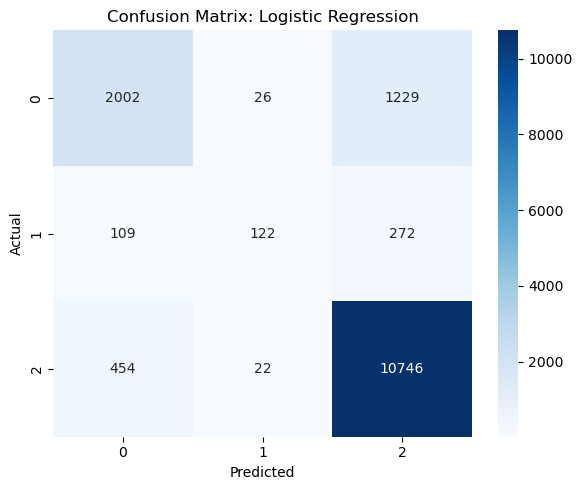

In [16]:
# Evaluate all models and collect results
results = []
results.append(evaluate_model(log_model, 'Logistic Regression', X_test, y_test))


Evaluating Model: SVM
Hyperparameters:
{'base_estimator': 'deprecated', 'cv': None, 'ensemble': True, 'estimator__C': 1.0, 'estimator__class_weight': None, 'estimator__dual': 'warn', 'estimator__fit_intercept': True, 'estimator__intercept_scaling': 1, 'estimator__loss': 'squared_hinge', 'estimator__max_iter': 5000, 'estimator__multi_class': 'ovr', 'estimator__penalty': 'l2', 'estimator__random_state': None, 'estimator__tol': 0.0001, 'estimator__verbose': 0, 'estimator': LinearSVC(max_iter=5000), 'method': 'sigmoid', 'n_jobs': None}
Accuracy: 0.8600
F1 Score (weighted): 0.8481

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.66      0.70      3257
           1       0.72      0.15      0.25       503
           2       0.89      0.95      0.92     11222

    accuracy                           0.86     14982
   macro avg       0.79      0.59      0.62     14982
weighted avg       0.85      0.86      0.85     14982



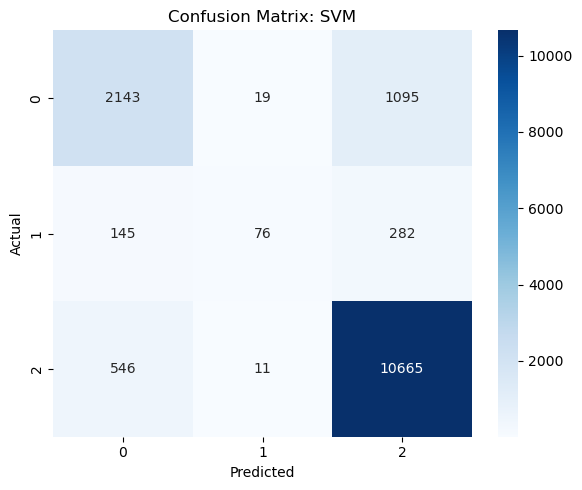

In [17]:
results.append(evaluate_model(svm_model, 'SVM', X_test, y_test))


Evaluating Model: Random Forest
Hyperparameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Accuracy: 0.7860
F1 Score (weighted): 0.7295

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.16      0.27      3257
           1       0.69      0.31      0.43       503
           2       0.79      0.99      0.88     11222

    accuracy                           0.79     14982
   macro avg       0.76      0.49      0.52     14982
weighted avg       0.79      0.79      0.73     14982



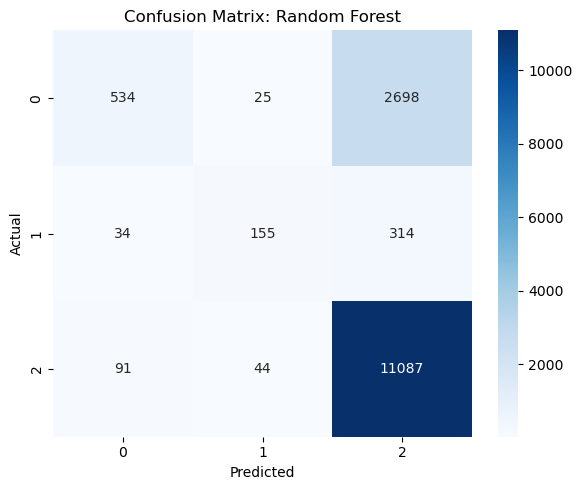

In [18]:
results.append(evaluate_model(rf_model, 'Random Forest', X_test, y_test))

In [20]:
#Display Performance Table
results_df = pd.DataFrame(results)
print("\nSummary of Model Performance:")
results_df


Summary of Model Performance:


,model,accuracy,f1_score
0,Logistic Regression,0.859031,0.847617
1,SVM,0.859965,0.848115
2,Random Forest,0.786010,0.729545


In [21]:
# Save vectorizer and label encoder for deployment
joblib.dump(vectorizer, os.path.join(MODEL_DIR, "tfidf_vectorizer_v1.joblib"))
joblib.dump(label_encoder, os.path.join(MODEL_DIR, "label_encoder_v1.joblib"))
print("Saved vectorizer and label encoder.")


Saved vectorizer and label encoder.


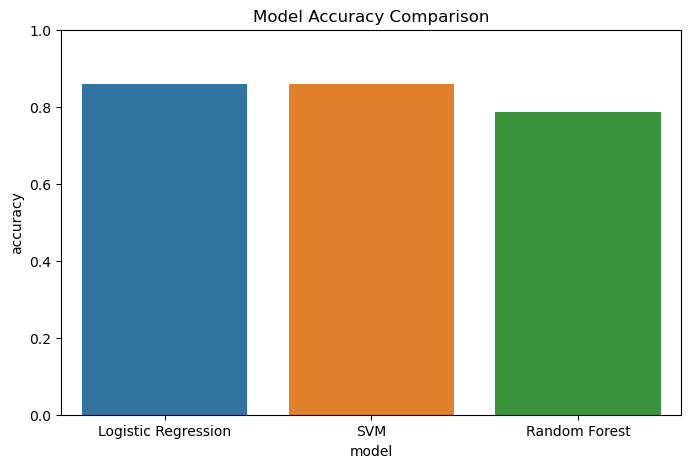

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='model', y='accuracy')
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

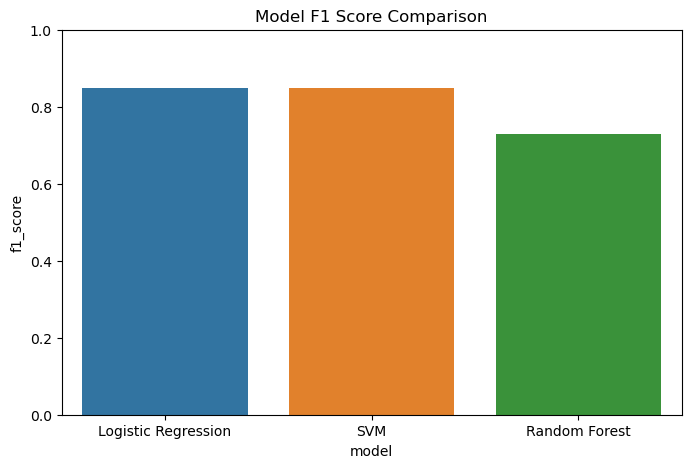

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='model', y='f1_score')
plt.title("Model F1 Score Comparison")
plt.ylim(0, 1)
plt.show()


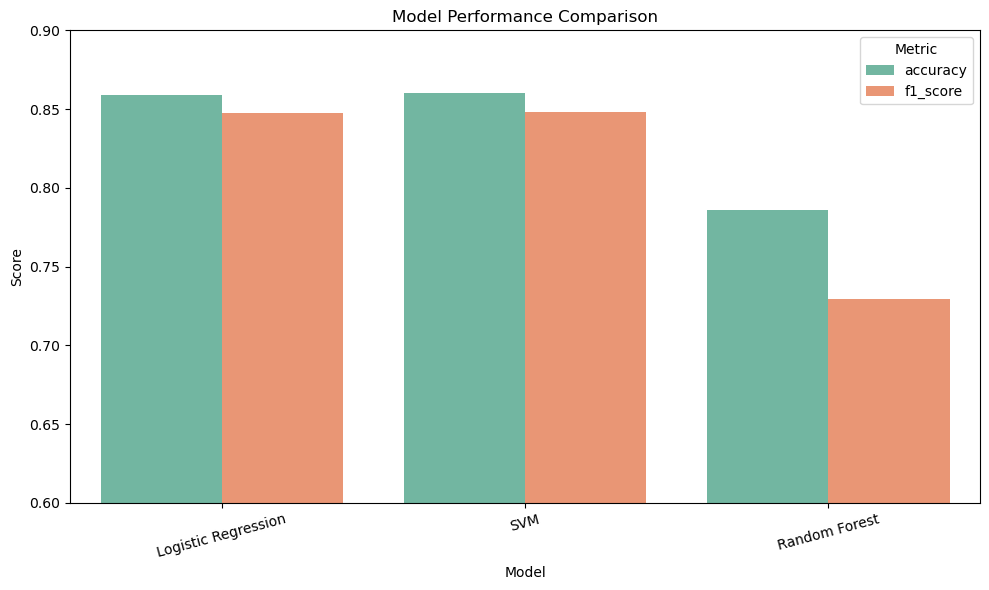

In [25]:
# Plot
plt.figure(figsize=(10, 6))
results_melted = results_df.melt(id_vars='model', value_vars=['accuracy', 'f1_score'], 
                                 var_name='Metric', value_name='Score')

sns.barplot(data=results_melted, x='model', y='Score', hue='Metric', palette='Set2')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.6, 0.9)
plt.xlabel('Model')
plt.legend(title='Metric')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()